# Ensemble + Swin Attention Maps

Este notebook aplica el ensemble de los tres planos, filtra casos con threshold = 0.3734 y muestra los mapas de atención (pesos por slice) del `SwinMultiSliceClassifier` ordenando las slices por su contribución a la decisión.

In [20]:
import os
import sys
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

sns.set_style('whitegrid')

sys.path.insert(0, str(Path('/home/palodo2/acl_classifier')))
from src.data_loader import OptimizedMRNetDataset, get_val_test_transform
from src.models import SwinMultiSliceClassifier

print('Imports listos')

Imports listos


In [21]:
# Configuración de rutas y constantes
BASE_DIR = Path('..').resolve().parent if Path('.').resolve().name != 'acl_classifier' else Path('..').resolve()
# si ejecutas desde el workspace, ajusta BASE_DIR a la raíz del proyecto
BASE_DIR = Path('/home/palodo2/acl_classifier')
DATA_DIR = BASE_DIR / 'data'
CHECKPOINTS_DIR = BASE_DIR / 'checkpoints'
RESULTS_DIR = BASE_DIR / 'final_model' / 'attention_maps_results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# Modelos Swin de checkpoints (ajusta si tus nombres son distintos)
SWIN_SMALL_MULTISEED_DIR = CHECKPOINTS_DIR / 'swin_small_multiseed'
SWIN_SMALL_MODELS = {
    'sagittal': SWIN_SMALL_MULTISEED_DIR / 'best_sagittal_multiseed_final.pth',
    'coronal': SWIN_SMALL_MULTISEED_DIR / 'best_coronal_multiseed_final.pth',
    'axial': SWIN_SMALL_MULTISEED_DIR / 'best_axial_multiseed_final.pth'
}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THRESHOLD = 0.3734
PLANES = ['sagittal','coronal','axial']
print('Config OK', DEVICE)

Config OK cuda


In [22]:
# Cargar modelos Swin (sólo forward y atención por slice)
swin_models = {}
for plane in PLANES:
    model_path = SWIN_SMALL_MODELS[plane]
    model = SwinMultiSliceClassifier()
    ck = torch.load(str(model_path), map_location=DEVICE, weights_only=False)
    if isinstance(ck, dict) and 'model_state_dict' in ck:
        model.load_state_dict(ck['model_state_dict'], strict=False)
    else:
        model.load_state_dict(ck, strict=False)
    model = model.to(DEVICE).eval()
    swin_models[plane] = model
print('Modelos Swin cargados: ', list(swin_models.keys()))

Modelos Swin cargados:  ['sagittal', 'coronal', 'axial']


In [23]:
# Preparar dataloader de test (usamos OptimizedMRNetDataset igual que en el notebook principal)
test_transform = get_val_test_transform()
TEST_CSV = DATA_DIR / 'test-acl.csv'
test_loaders = {}
test_all_labels = None
for plane in PLANES:
    ds = OptimizedMRNetDataset(
        csv_path=str(TEST_CSV),
        data_root=str(DATA_DIR / 'test'),
        plane=plane,
        indices_cache_path=str(DATA_DIR / 'slice_indices_final' / f'test_{plane}_indices.json'),
        transform=test_transform
    )
    test_loaders[plane] = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    if test_all_labels is None:
        test_all_labels = ds.df['label'].values
    print(f'{plane}: {len(ds)} casos')
print('Test loaders listos')

✓ Dataset cargado: 187 casos
  Plane: sagittal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_sagittal_indices.json
sagittal: 187 casos
✓ Dataset cargado: 187 casos
  Plane: coronal
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_coronal_indices.json
coronal: 187 casos
✓ Dataset cargado: 187 casos
  Plane: axial
  Augmentation: None (usando transform directo)
  Índices cacheados: /home/palodo2/acl_classifier/data/slice_indices_final/test_axial_indices.json
axial: 187 casos
Test loaders listos


In [24]:
# Obtener predicciones por plano y ensemble
def get_probs_for_loader(model, loader, device):
    model.eval()
    all_probs = []
    all_ids = []
    with torch.no_grad():
        for batch in loader:
            imgs, labels = batch if len(batch) == 2 else (batch[0], batch[1])
            imgs = imgs.to(device)
            logits, attn = model(imgs)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs.tolist())
            # try to extract ids if present
            if len(batch) == 3:
                all_ids.extend(batch[2])
    return np.array(all_probs), all_ids

plane_probs = {}
for plane in PLANES:
    probs, ids = get_probs_for_loader(swin_models[plane], test_loaders[plane], DEVICE)
    plane_probs[plane] = probs
    print(f'{plane} AUC calc skipped here; probs shape:', probs.shape)

# Ensemble ponderado igual que en el notebook original
weights = {'sagittal': 1/3, 'coronal':1/3, 'axial':1/3}
ensemble = np.zeros_like(plane_probs[PLANES[0]])
for p in PLANES:
    ensemble += weights[p] * plane_probs[p]
print('Ensemble calculado.')
# Indices de casos que cumplen threshold
selected_idx = np.where(ensemble >= THRESHOLD)[0]
print(f'Casos con ensemble >= {THRESHOLD}:', len(selected_idx))

sagittal AUC calc skipped here; probs shape: (187,)
coronal AUC calc skipped here; probs shape: (187,)
axial AUC calc skipped here; probs shape: (187,)
Ensemble calculado.
Casos con ensemble >= 0.3734: 62


In [35]:
import torch.nn.functional as F


def get_case_plane_data(model, ds, case_idx, device):
    """Devuelve las slices del caso, sus pesos de atención por slice y la probabilidad del plano."""
    model.eval()
    item = ds[case_idx]
    slices_rgb = item[0]  # (K, 3, H, W)
    x = slices_rgb.unsqueeze(0).to(device)
    with torch.no_grad():
        logits, attn = model(x)
    attn = attn.cpu().numpy().ravel() if attn is not None else None
    prob = float(torch.sigmoid(logits).cpu().item())
    return slices_rgb, attn, prob


def swin_spatial_cam_for_slice(model, slice_rgb, device):
    """Grad-CAM espacial real sobre la rejilla 7x7 del Swin para una slice individual."""
    model.eval()
    x = slice_rgb.unsqueeze(0).to(device)  # (1, 3, H, W)
    x.requires_grad_(True)

    model.backbone.zero_grad(set_to_none=True)
    model.zero_grad(set_to_none=True)

    feat_map = model.backbone.forward_features(x)  # (1, 7, 7, 768)
    if feat_map.dim() != 4:
        raise ValueError(f'forward_features devolvió una forma inesperada: {tuple(feat_map.shape)}')
    feat_map.retain_grad()

    feat_vec = model.backbone.forward_head(feat_map, pre_logits=True)  # (1, 768)
    pooled_features, _ = model.pooling(feat_vec.unsqueeze(1))  # (1, 768)
    logits = model.classifier(pooled_features)  # (1, 1)

    score = logits.squeeze()
    score.backward()

    grads = feat_map.grad  # (1, 7, 7, 768)
    weights = grads.mean(dim=(1, 2), keepdim=True)  # (1, 1, 1, 768)
    cam = F.relu((weights * feat_map).sum(dim=-1, keepdim=False))  # (1, 7, 7)
    cam = cam.unsqueeze(1)
    cam = F.interpolate(cam, size=slice_rgb.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    pred_prob = float(torch.sigmoid(score).detach().cpu().item())
    return cam, pred_prob


def plot_case_spatial_heatmaps(case_results, out_path=None, top_n=None, title=None, heat_alpha=0.12, heat_cmap='magma'):
    """Muestra los 3 planos para un caso con Grad-CAM espacial real por slice, con overlay suave y contornos visibles."""
    planes = list(case_results.keys())
    n_planes = len(planes)
    max_k = top_n if top_n is not None else max(len(case_results[p]['attn']) for p in planes)

    fig, axes = plt.subplots(n_planes, max_k, figsize=(4 * max_k, 4 * n_planes), squeeze=False)

    for row, plane in enumerate(planes):
        data = case_results[plane]
        attn = data['attn']
        order = np.argsort(attn)[::-1]
        if top_n is not None:
            order = order[:top_n]

        for col in range(max_k):
            ax = axes[row, col]
            if col >= len(order):
                ax.axis('off')
                continue

            idx = order[col]
            slice_rgb = data['slices_rgb'][idx].detach().cpu().numpy()
            cam = data['cams'][idx]

            # Realce suave por percentiles para que no tape la resonancia
            cam_low = np.percentile(cam, 30)
            cam_high = np.percentile(cam, 99)
            cam_vis = np.clip((cam - cam_low) / (cam_high - cam_low + 1e-8), 0, 1)
            cam_vis = np.power(cam_vis, 0.60)

            gray = slice_rgb.mean(axis=0)
            gray = gray - gray.min()
            gray = gray / (gray.max() + 1e-8)

            ax.imshow(gray, cmap='gray', interpolation='nearest')
            ax.imshow(cam_vis, cmap=heat_cmap, alpha=heat_alpha, vmin=0, vmax=1, interpolation='bilinear')
            ax.contourf(cam_vis, levels=[0.40, 0.60, 0.80, 1.00], cmap=heat_cmap, alpha=0.08)
            ax.contour(cam_vis, levels=[0.40, 0.60, 0.80], colors=['white', 'yellow', 'red'], linewidths=[0.6, 0.8, 1.0], alpha=0.75)
            ax.set_title(f'{plane} | slice {idx}\nattn={attn[idx]:.3f}', fontsize=9)
            ax.axis('off')

    if title:
        fig.suptitle(title, y=1.01, fontsize=14)

    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()


def summarize_case_prediction(case_idx, plane_probs, ensemble_prob, threshold):
    rows = []
    for plane, prob in plane_probs.items():
        rows.append({'plane': plane, 'probability': float(prob)})
    rows.append({'plane': 'ensemble', 'probability': float(ensemble_prob)})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    print(f'Case {case_idx}: ensemble={ensemble_prob:.4f} | threshold={threshold:.4f} | prediction={int(ensemble_prob >= threshold)}')

   plane  probability
sagittal     0.876769
 coronal     0.976391
   axial     0.988515
ensemble     0.947225
Case 0: ensemble=0.9472 | threshold=0.3734 | prediction=1


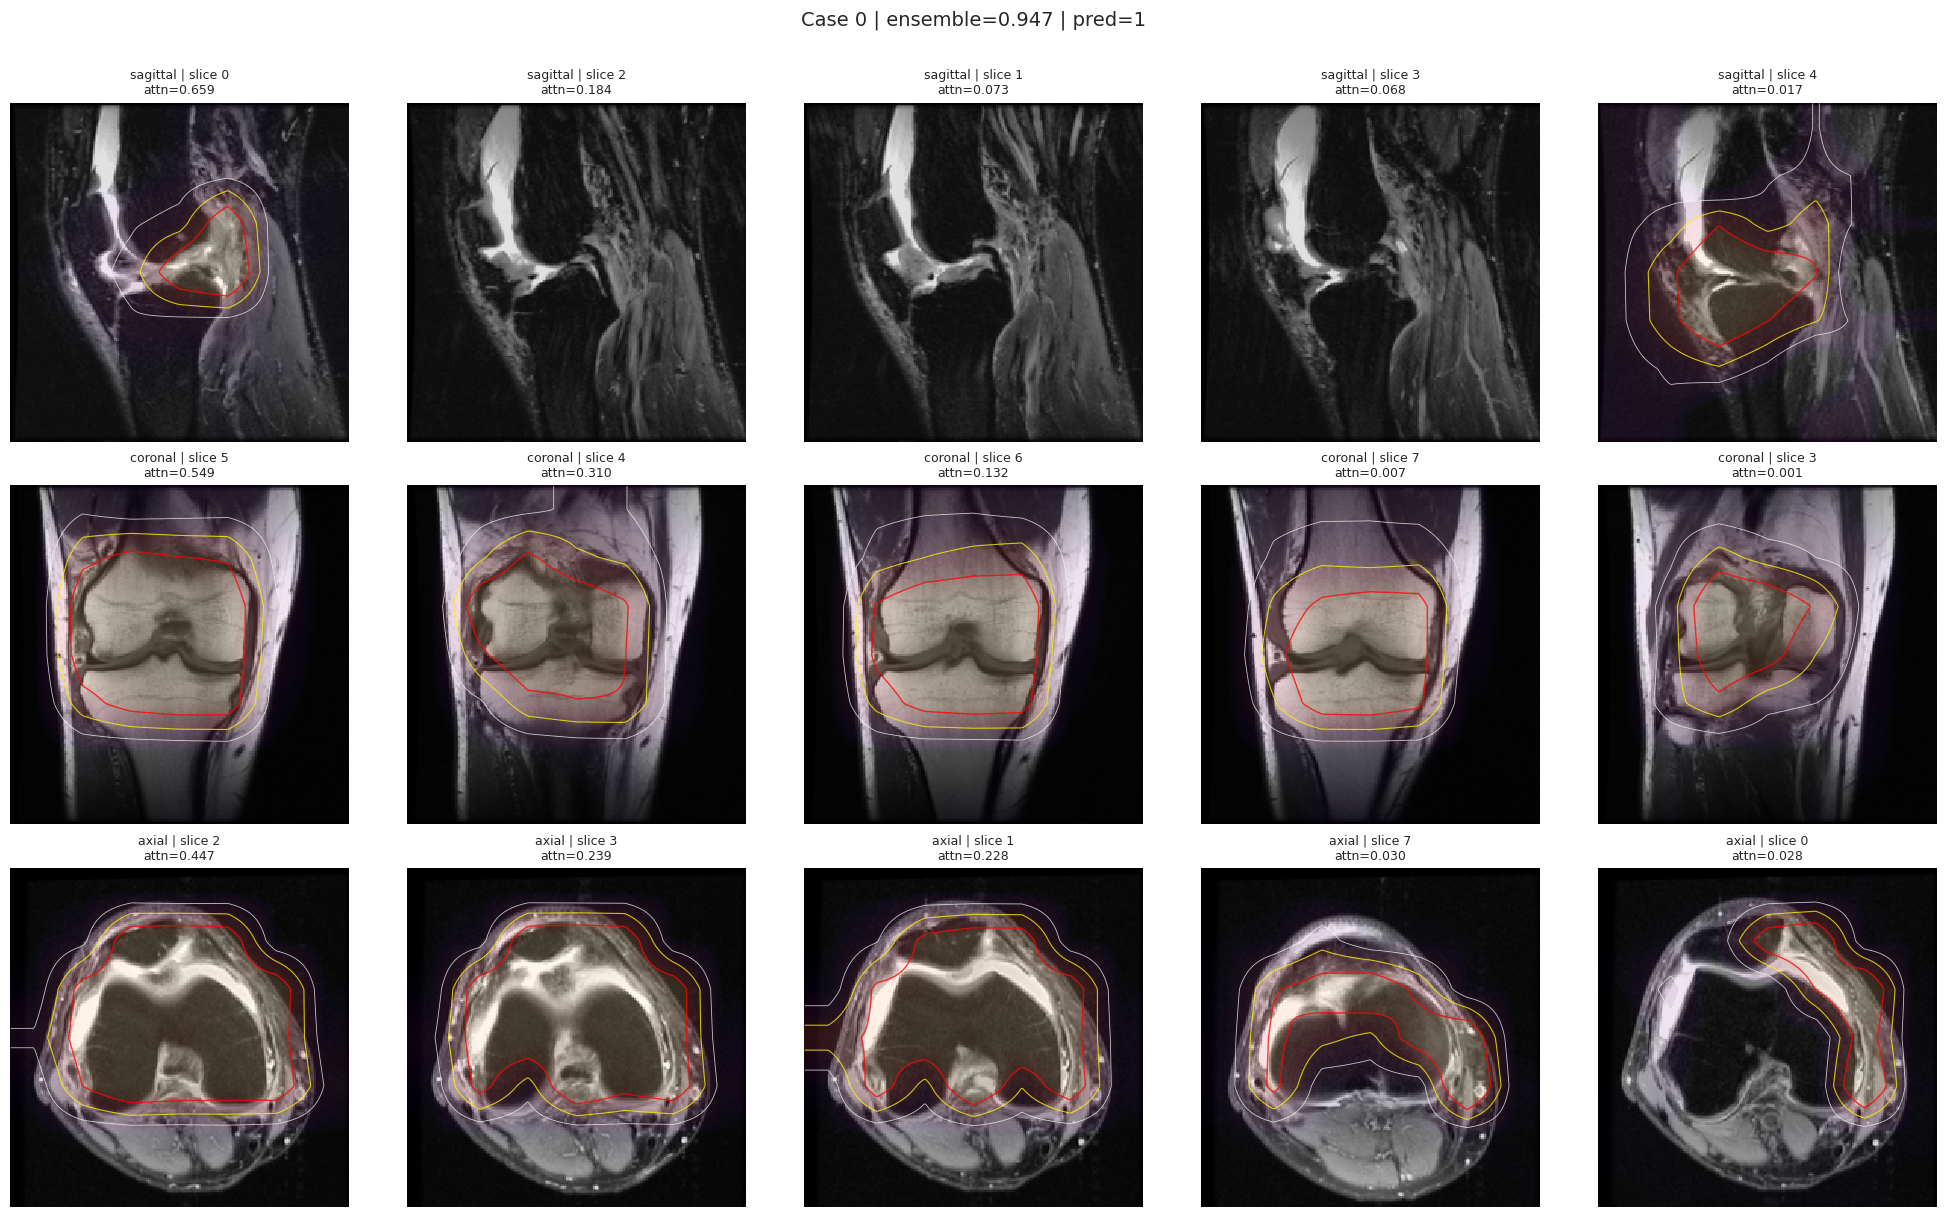

Guardado: /home/palodo2/acl_classifier/final_model/attention_maps_results/case_000_all_planes_spatial_gradcam.png
Esto ya usa la rejilla espacial real 7x7 del Swin para cada slice.


In [36]:
# Caso por caso: seleccionar un índice y visualizarlo
CASE_INDEX = 0  # cambia este índice para revisar otro caso del test set
TOP_N_SLICES = 5

# Obtener predicciones del ensemble para el caso elegido y almacenar atención por plano
case_plane_probs = {}
case_results = {}

for plane in PLANES:
    slices_rgb, attn, prob = get_case_plane_data(
        swin_models[plane],
        test_loaders[plane].dataset,
        CASE_INDEX,
        DEVICE
    )
    case_plane_probs[plane] = prob

    order = np.argsort(attn)[::-1][:TOP_N_SLICES]
    cams = {}
    for idx in order:
        cam, _ = swin_spatial_cam_for_slice(
            swin_models[plane],
            slices_rgb[idx],
            DEVICE
        )
        cams[idx] = cam

    case_results[plane] = {
        'slices_rgb': slices_rgb,
        'attn': attn,
        'cams': cams,
    }

case_ensemble_prob = sum(weights[p] * case_plane_probs[p] for p in PLANES)
case_pred = int(case_ensemble_prob >= THRESHOLD)

summarize_case_prediction(CASE_INDEX, case_plane_probs, case_ensemble_prob, THRESHOLD)

out_png = RESULTS_DIR / f'case_{CASE_INDEX:03d}_all_planes_spatial_gradcam.png'
plot_case_spatial_heatmaps(
    case_results,
    out_path=out_png,
    top_n=TOP_N_SLICES,
    title=f'Case {CASE_INDEX} | ensemble={case_ensemble_prob:.3f} | pred={case_pred}'
)
print('Guardado:', out_png)
print('Esto ya usa la rejilla espacial real 7x7 del Swin para cada slice.')

Notas:
- El notebook usa los pesos del `SwinMultiSliceClassifier` y muestra el calor por slice que proviene del pooling de atención (peso por slice).
- En la vista actual hay **overlay de calor** sobre cada slice y una barra de peso para que se vea qué cortes influyen más.
- Si quieres mapas de calor **espaciales** dentro de cada slice (patch-level attention), hay que añadir Grad-CAM o attention rollout sobre el `backbone` de `timm`.
- Ajusta `CASE_INDEX` y `TOP_N_SLICES` según quieras revisar más o menos slices por caso.